In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error,mean_absolute_error,root_mean_squared_error,r2_score

* sklearn is from the scikit-learn package
* linear_model is one module in scikit-learn package
* LinearRegression is a one class in the linear_model module

In [ ]:
df =  pd.read_csv('Salary_Data.csv')

In [ ]:
df.head()

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  30 non-null     float64
 1   Salary           30 non-null     float64
dtypes: float64(2)
memory usage: 612.0 bytes


In [ ]:
df.corr()

,YearsExperience,Salary
YearsExperience,1.000000,0.978242
Salary,0.978242,1.000000


## Conclusion
* Salary(Target) column is strongly correlated to feature column named YearsExperience
* The data is linearly correleated

In [ ]:
# x = df[['YearsExperience']]
# y = df['Salary']

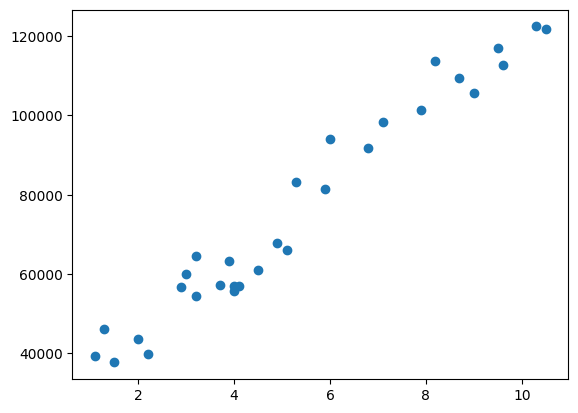

In [ ]:
# plt.scatter(x, y)
plt.scatter(df['YearsExperience'],df['Salary'])

## Scenario 1

### Step 1  segreating the x and y


In [ ]:
x = df[['YearsExperience']]
y = df['Salary']

### Step 2 Traing the model
* LinearRegression is a class, to access it we have to create a object reference 

In [ ]:
model = LinearRegression()

## Syntax for fit() method

* modelname.fit(xtrain,ytrain)
* mostly we use this method for the model training
* here xtrain should 2D and ytrain should be 1D
* the fit() method it learns pattern for the equation y= mx+c it finds the values of m and c

* slope = model.coef_
* intercept = model.intercept_

In [ ]:
# model.fit(x,y)

### Step 3:-

* predict the outputs for the new inputs

### we use predict() method to predict outputs based on new input

* syntax:- model.predict(x)
* we use the predict in 2 secniors, for evaluation of the model and for feature predictions
* note:- here we pass only x(i.e new input), we should not pass y values, because we are going to predict outputs for new inputs


In [ ]:
# model.predict(x)

In [ ]:
# model.predict([[20]])

In [ ]:
# slope = model.coef_
# slope

In [ ]:
# intercept = model.intercept_
# intercept

### conclusion for slope
* when the x is inceresed by one unit each time the y will increase by 9449.96232146
* for yearsExperince is increased by one year the salary will get incerese by 9449.96232146

### Conclusion for intercept
*  The initial value of y is 25792.20019866871 when the x is 0
* The initial salary will be the 25792.20019866871 when the experinece is 0 or the fresher

In [ ]:
x = df.drop('Salary',axis=1)
y = df['Salary']

In [ ]:
xtrain,xtest,ytrain,ytest = train_test_split(x,y,train_size=0.8,random_state=42)

In [ ]:
xtrain

,YearsExperience
28,10.3
24,8.7
12,4.0
0,1.1
4,2.2
16,5.1
5,2.9
13,4.1
11,4.0
22,7.9


In [ ]:
xtest

,YearsExperience
27,9.6
15,4.9
23,8.2
17,5.3
8,3.2
9,3.7


In [ ]:
model.fit(xtrain,ytrain)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [ ]:
model.predict(xtest)

array([115790.21011287,  71498.27809463, 102596.86866063,  75267.80422384,
        55477.79204548,  60189.69970699])

In [ ]:
slope = model.coef_
slope

array([9423.81532303])

In [ ]:
intercept = model.intercept_
intercept

np.float64(25321.583011776813)

In [ ]:
ypred_train= model.predict(xtrain)

In [ ]:
ytrain - ypred_train

28        4.119161
24     2122.223678
12    -6059.844304
0      3655.220133
4     -6162.976722
16    -7354.041159
5      3991.352551
13    -6878.225836
11    -7222.844304
22     1532.275936
1      8632.457068
2     -1726.305996
25    -4553.920919
3      -644.213658
21     6042.328195
26     2121.171419
18      440.906582
29    -2399.643904
20     2334.472792
7     -1032.792045
10     1143.537228
14    -6617.751965
19    12075.525050
6      6556.971019
Name: Salary, dtype: float64

#### Syntax for metrics

metric_name(ytrue,ypred)

In [ ]:
r2_score(ytrain,ypred_train)

0.9645401573418146